In [1]:
import torch
import torch.nn
import pandas as pd
import numpy
import torch.nn.functional
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
## Prepare Data set



In [2]:
temp_data=pd.read_csv(r'C:\Users\administrator\python_practice\current_out_all_clean_data.csv', low_memory=False)
temp_data['purpose']

y_temp=temp_data['total_rec_prncp']/temp_data['funded_amnt']

In [3]:
def clean_data(x):
    x.replace([numpy.inf], 0, inplace=True)
    x.replace([numpy.NAN], 0, inplace=True)

clean_data(y_temp)

# 'revol_util' 열의 모든 값을 문자열로 변환 후 '%' 기호를 제거하고 float로 변환
temp_data['revol_util'] = temp_data['revol_util'].astype(str).str.replace('%', '').astype(float)

temp_data.drop('id', axis=1, inplace=True)

select_feature = '''
loan_amnt
term
int_rate
installment
sub_grade
emp_length
home_ownership
annual_inc
verification_status
purpose
dti
delinq_2yrs
fico_range_high
mths_since_last_delinq
open_acc
pub_rec
revol_util
total_acc
initial_list_status
last_fico_range_high
collections_12_mths_ex_med
mths_since_last_major_derog
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
max_bal_bc
all_util
total_rev_hi_lim
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc_util
chargeoff_within_12_mths
delinq_amnt
mo_sin_old_il_acct
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_inq
mths_since_recent_revol_delinq
num_accts_ever_120_pd
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_il_tl
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_90g_dpd_24m
num_tl_op_past_12m
pct_tl_nvr_dlq
percent_bc_gt_75
pub_rec_bankruptcies
tax_liens
tot_hi_cred_lim
total_bal_ex_mort
total_bc_limit
total_il_high_credit_limit
revol_bal_joint
sec_app_fico_range_low
sec_app_fico_range_high
sec_app_inq_last_6mths
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_collections_12_mths_ex_med
'''
# 선택된 피처들로 데이터프레임 생성 (bar_ex_mort_year, bar_il_year, loan_year 제외)
select_feature = select_feature.strip().split('\n')
x_temp = temp_data[select_feature].reset_index(drop=True)

# 새로운 피처 추가 (선택된 피처 생성 후 추가)
x_temp['bar_ex_mort_year'] = x_temp['total_bal_ex_mort'] / x_temp['annual_inc']
x_temp['bar_il_year'] = x_temp['total_bal_il'] / x_temp['annual_inc']
x_temp['loan_year'] = x_temp['loan_amnt'] / x_temp['annual_inc']

# 결측값 및 무한대 값 처리
clean_data(x_temp)

# x_temp 데이터프레임 확인
print(x_temp.head())

   loan_amnt  term  int_rate  installment  sub_grade  emp_length  \
0     6000.0    36      7.97       187.94          4         2.0   
1    23200.0    60     24.99       680.82         23        10.0   
2    16000.0    36      7.07       494.55          1         0.0   
3     4500.0    36     10.42       146.10          7         5.0   
4    20000.0    36      9.99       645.25          7        10.0   

  home_ownership  annual_inc verification_status             purpose  ...  \
0       MORTGAGE     45000.0            Verified  debt_consolidation  ...   
1       MORTGAGE    110000.0            Verified  debt_consolidation  ...   
2       MORTGAGE     65000.0        Not Verified    home_improvement  ...   
3       MORTGAGE     50000.0        Not Verified    home_improvement  ...   
4       MORTGAGE     60000.0     Source Verified         credit_card  ...   

   sec_app_inq_last_6mths  sec_app_mort_acc  sec_app_open_acc  \
0                     0.0               0.0              10.0  

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# 데이터셋 분할 함수
def splitset(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
    return x_train.reset_index(drop=True), y_train.reset_index(drop=True), \
           x_valid.reset_index(drop=True), y_valid.reset_index(drop=True), \
           x_test.reset_index(drop=True), y_test.reset_index(drop=True)

# One-Hot Encoding 및 Standard Scaling 함수
def onehot_train_valid(x_train, x_valid, x_test):
    one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    temp_data_train = x_train.select_dtypes(include='object')
    temp_data_valid = x_valid.select_dtypes(include='object')
    temp_data_test = x_test.select_dtypes(include='object')
    
    one.fit(temp_data_train)
    
    temp_x_train = one.transform(temp_data_train)
    temp_x_valid = one.transform(temp_data_valid)
    temp_x_test = one.transform(temp_data_test)
    
    columns = one.get_feature_names_out(temp_data_train.columns)
    
    temp_final_train = pd.DataFrame(temp_x_train, columns=columns)
    temp_final_valid = pd.DataFrame(temp_x_valid, columns=columns)
    temp_final_test = pd.DataFrame(temp_x_test, columns=columns)
    
    return temp_final_train, temp_final_valid, temp_final_test

def stsc_train_valid(x_train, x_valid, x_test):
    stdsc = StandardScaler()
    temp_x_train = x_train.select_dtypes(exclude='object')
    temp_x_valid = x_valid.select_dtypes(exclude='object')
    temp_x_test = x_test.select_dtypes(exclude='object')
    
    name = temp_x_train.columns
    stdsc.fit(temp_x_train)
    
    temp_x_train = stdsc.transform(temp_x_train)
    temp_x_valid = stdsc.transform(temp_x_valid)
    temp_x_test = stdsc.transform(temp_x_test)
    
    temp_x_train = pd.DataFrame(temp_x_train, columns=name)
    temp_x_valid = pd.DataFrame(temp_x_valid, columns=name)
    temp_x_test = pd.DataFrame(temp_x_test, columns=name)
    
    return temp_x_train, temp_x_valid, temp_x_test

# 데이터셋 로드 및 분할 (x_temp, y_temp는 기존에 정의된 데이터셋)
bx_train, y_train, bx_valid, y_valid, bx_test, y_test = splitset(x_temp, y_temp)

# One-Hot Encoding 및 Scaling 적용
one_train, one_valid, one_test = onehot_train_valid(bx_train, bx_valid, bx_test)
stsc_train, stsc_valid, stsc_test = stsc_train_valid(bx_train, bx_valid, bx_test)

# 최종 학습, 검증, 테스트 데이터셋 생성
x_train = pd.concat([stsc_train, one_train], axis=1)
x_valid = pd.concat([stsc_valid, one_valid], axis=1)
x_test = pd.concat([stsc_test, one_test], axis=1)

# 전처리된 데이터 사용
x_train = x_train.to_numpy()
y_train = y_train.to_numpy().ravel()
x_valid = x_valid.to_numpy()
y_valid = y_valid.to_numpy().ravel()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy().ravel()

Fitting 2 folds for each of 100 candidates, totalling 200 fits


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
13 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\sklearn.py", line 1108, in fit
    self._Booster = trai

Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 17, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [10:20:00] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [10:20:00] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Validation Set Performance:
RMSE: 0.2119307934253434
MSE: 0.044914661201895585
MAE: 0.09123661657984118
Test Set Performance:
RMSE: 0.2121990223714596
MSE: 0.04502842509540321
MAE: 0.09147593882480048


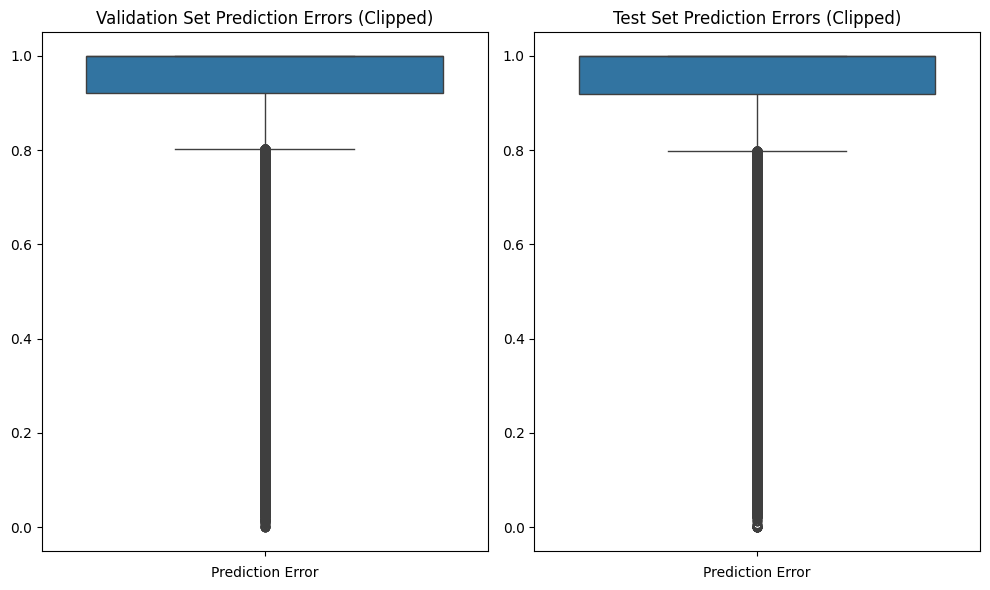

In [5]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 하이퍼파라미터 설정
params = {
    'objective': ['reg:absoluteerror'],  # Mean Absolute Error로 설정
    'max_depth': np.arange(1, 16, 1),  # 더 깊은 트리를 시도
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # 더 작은 학습률 추가
    'n_estimators': [100, 300, 500],  # 중간 값 추가
    'colsample_bytree': [0.6, 0.8, 1.0],  # 각 트리에 대한 특성 샘플링 비율
    'gamma': [0, 0.1, 0.5, 1],  # 가지치기 결정에 영향을 미치는 감마 값
    'min_child_weight': np.arange(5, 25, 3),  # 리프 노드가 가져야 하는 최소 가중치 합
    'tree_method': ['gpu_hist'],  # GPU 사용을 위한 'gpu_hist' 설정
    'random_state': [101]
}

# XGBoost 모델 초기화
xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=100, cv=2, verbose=1, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# 예측 값 클리핑 (0 미만은 0, 1 이상은 1로)
y_pred_val_clipped = np.clip(y_pred_val, 0, 1)
y_pred_test_clipped = np.clip(y_pred_test, 0, 1)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val_clipped))
val_mse = mean_squared_error(y_valid, y_pred_val_clipped)
val_mae = mean_absolute_error(y_valid, y_pred_val_clipped)

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_clipped))
test_mse = mean_squared_error(y_test, y_pred_test_clipped)
test_mae = mean_absolute_error(y_test, y_pred_test_clipped)

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

# 박스플롯 그리기
plt.figure(figsize=(10, 6))

# Validation Set 박스플롯
plt.subplot(1, 2, 1)
sns.boxplot(y_pred_val_clipped)
plt.title('Validation Set Prediction Errors (Clipped)')
plt.xlabel('Prediction Error')

# Test Set 박스플롯
plt.subplot(1, 2, 2)
sns.boxplot(y_pred_test_clipped)
plt.title('Test Set Prediction Errors (Clipped)')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()


In [6]:
# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 17, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


Number of features with positive importance: 34

Positive Feature Importance:
                               Feature  Importance
9                              pub_rec    0.910002
1                             int_rate    0.086655
3                            sub_grade    0.076381
0                                 term    0.069961
13                         open_il_24m    0.038789
29                  sec_app_revol_util    0.003927
5                           annual_inc    0.002817
2                          installment    0.002122
4                           emp_length    0.001399
7                              purpose    0.000857
20                 num_rev_tl_bal_gt_0    0.000673
26                     revol_bal_joint    0.000654
22                pub_rec_bankruptcies    0.000540
16                         avg_cur_bal    0.000425
8                      fico_range_high    0.000132
24                   total_bal_ex_mort    0.000107
17                mo_sin_old_rev_tl_op    0.000107
14  

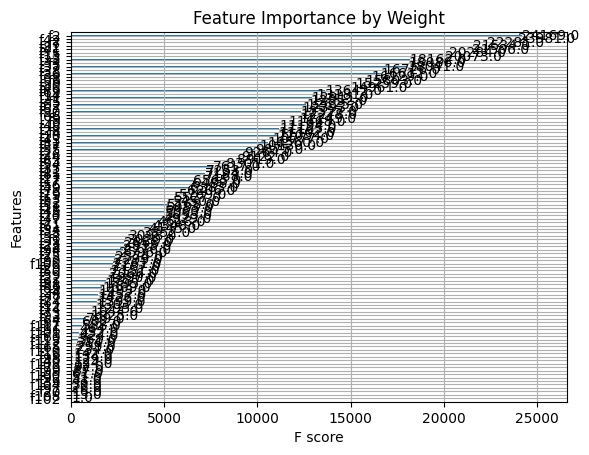

In [8]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance  # permutation_importance 임포트
import xgboost as xgb
import matplotlib.pyplot as plt

# 전처리 단계에서 피처 이름을 저장해두기
feature_names = bx_train.columns  # 원래 DataFrame의 컬럼 이름을 저장

# Permutation Importance 계산
perm_importance = permutation_importance(best_model, x_valid, y_valid, n_repeats=10, random_state=101)

# 피처 중요도와 피처 이름 매핑
importance_values = perm_importance.importances_mean
feature_importance_dict = dict(zip(feature_names, importance_values))

# 양수 중요도와 피처 이름 매핑
positive_importance = {feature: importance for feature, importance in feature_importance_dict.items() if importance >= 0}

# 데이터프레임으로 변환
df_positive_importance = pd.DataFrame(list(positive_importance.items()), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# 양수 중요도 피처 수 계산
num_positive_features = len(positive_importance)

# 결과 출력
print(f"Number of features with positive importance: {num_positive_features}")

print("\nPositive Feature Importance:")
print(df_positive_importance)

# Feature importance plot (XGBoost 내장 기능 사용)
xgb.plot_importance(best_model, importance_type='weight', title='Feature Importance by Weight')
plt.show()

In [9]:
# 양수 중요도를 가장 작은 수에서 큰 수로 정렬
df_positive_importance_sorted = df_positive_importance.sort_values(by='Importance', ascending=True)

# 피처 이름과 중요도 수치를 텍스트 파일로 저장
positive_features = df_positive_importance_sorted[['Feature', 'Importance']].values.tolist()

with open("positive_features_sorted.txt", "w") as file:
    file.write(f"Total number of features with positive importance: {len(positive_features)}\n")
    file.write("Features with positive importance (sorted from smallest to largest):\n")
    for feature, importance in positive_features:
        file.write(f"{feature}: {importance}\n")

print("Sorted features with positive importance and their values have been saved to 'positive_features_sorted.txt'")

Sorted features with positive importance and their values have been saved to 'positive_features_sorted.txt'


Fitting 2 folds for each of 100 candidates, totalling 200 fits


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [16:19:11] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Best parameters found:  {'tree_method': 'gpu_hist', 'random_state': 101, 'objective': 'reg:absoluteerror', 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 15, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}


c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [16:19:40] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\administrator\anaconda3\envs\moment\lib\site-packages\xgboost\core.py:158: UserWarning: [16:19:40] WARNING: D:\bld\xgboost-split_1724807729805\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Validation Set Performance:
RMSE: 0.2091544312917099
MSE: 0.043745576128958595
MAE: 0.09581133447059477
Test Set Performance:
RMSE: 0.20960982185792357
MSE: 0.04393627741931045
MAE: 0.09617813133198919
Permutation Importance of each feature:
Feature 0: 0.0005434315618738639
Feature 1: 0.05676416687004898
Feature 2: 0.4234911998643045
Feature 3: -0.001113419116790304
Feature 4: 0.3158111774056968
Feature 5: 0.0019785481632922817
Feature 6: 0.000107851797945413
Feature 7: 0.003884695044098929
Feature 8: 6.361113579667066e-06
Feature 9: 0.0012361182368309965
Feature 10: -0.0002706704698555051
Feature 11: -0.00023195327677726362
Feature 12: 0.00018611282704367182
Feature 13: -0.0005158382997819455
Feature 14: -0.0001850171586331273
Feature 15: 0.8729352757007005
Feature 16: -3.971443142747333e-06
Feature 17: -0.00013193013371741723
Feature 18: -6.078764229145994e-05
Feature 19: 6.628325000436197e-05
Feature 20: -3.993956520553788e-06
Feature 21: -0.0008501276173424443
Feature 22: -0.000196

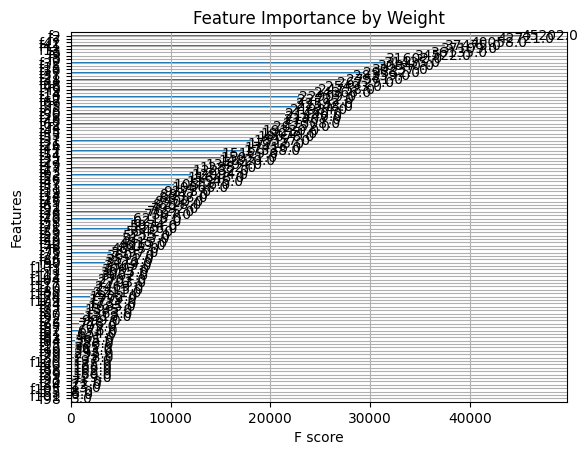

In [8]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# 하이퍼파라미터 설정
params = {
    'objective': ['reg:absoluteerror'],  # Mean Absolute Error로 설정
    'max_depth': np.arange(1, 16, 1),  # 더 깊은 트리를 시도
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # 더 작은 학습률 추가
    'n_estimators': [100, 300, 500],  # 중간 값 추가
    'colsample_bytree': [0.6, 0.8, 1.0],  # 각 트리에 대한 특성 샘플링 비율
    'gamma': [0, 0.1, 0.5, 1],  # 가지치기 결정에 영향을 미치는 감마 값
    'min_child_weight': np.arange(5, 25, 3),  # 리프 노드가 가져야 하는 최소 가중치 합
    'tree_method': ['gpu_hist'],  # GPU 사용을 위한 'gpu_hist' 설정
    'random_state': [101]
}

# XGBoost 모델 초기화
xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=100, cv=2, verbose=1, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
val_mse = mean_squared_error(y_valid, y_pred_val)
val_mae = mean_absolute_error(y_valid, y_pred_val)

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

# Permutation Importance 계산
perm_importance = permutation_importance(best_model, x_valid, y_valid, n_repeats=10, random_state=101)

# Permutation Importance 결과 출력
print("Permutation Importance of each feature:")
for i in range(len(perm_importance.importances_mean)):
    print(f"Feature {i}: {perm_importance.importances_mean[i]}")

# Feature importance plot (XGBoost 내장 기능 사용)
xgb.plot_importance(best_model, importance_type='weight', title='Feature Importance by Weight')
plt.show()

Permutation Importance of each feature:
pub_rec: 0.8729352757007005
int_rate: 0.4234911998643045
sub_grade: 0.3158111774056968
term: 0.05676416687004898
open_il_24m: 0.022523807622473947
annual_inc: 0.003884695044098929
emp_length: 0.0019785481632922817
revol_bal_joint: 0.001534322168497093
purpose: 0.0012361182368309965
total_bal_ex_mort: 0.0011055867383365724
tax_liens: 0.0007759628675375718
loan_amnt: 0.0005434315618738639
num_rev_tl_bal_gt_0: 0.0005091796478187138
pub_rec_bankruptcies: 0.0004161798842129416
fico_range_high: 0.00018611282704367182
acc_open_past_24mths: 0.00018346897056300548
open_rv_12m: 0.00013289362863009302
home_ownership: 0.000107851797945413
last_fico_range_high: 6.628325000436197e-05
mo_sin_old_rev_tl_op: 5.110969259414233e-05
sec_app_inq_last_6mths: 4.814113486636407e-05
mo_sin_rcnt_tl: 3.4876479526757545e-05
sec_app_revol_util: 2.950692793681764e-05
total_bal_il: 2.5251222086941637e-05
num_sats: 1.9581570586546525e-05
sec_app_open_acc: 9.061658551900997e-06


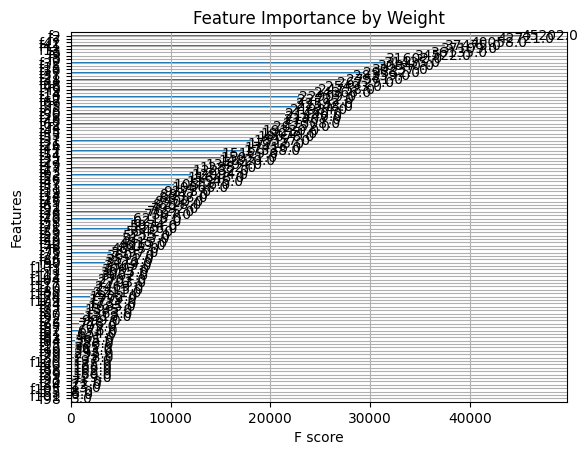

In [10]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# 전처리 단계에서 피처 이름을 저장해두기
feature_names = bx_train.columns  # 원래 DataFrame의 컬럼 이름을 저장

# Permutation Importance 계산
perm_importance = permutation_importance(best_model, x_valid, y_valid, n_repeats=10, random_state=101)

# 피처 중요도와 피처 이름 매핑
importance_values = perm_importance.importances_mean

# 피처 이름과 중요도를 매핑한 딕셔너리 생성
feature_importance_dict = dict(zip(feature_names, importance_values))

# 중요도에 따라 피처를 정렬
sorted_importance = sorted(feature_importance_dict.items(), key=lambda item: item[1], reverse=True)

# 결과 출력
print("Permutation Importance of each feature:")
for feature, importance in sorted_importance:
    print(f"{feature}: {importance}")

# Feature importance plot (XGBoost 내장 기능 사용)
xgb.plot_importance(best_model, importance_type='weight', title='Feature Importance by Weight')
plt.show()

In [17]:
params = {
    'objective': ['reg:squarederror'],
    'max_depth': [3, 6, 9, 12],  # 더 깊은 트리를 시도
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # 더 작은 학습률 추가
    'n_estimators': [100, 300, 500, 1000],  # 중간 값 추가
    'subsample': [0.6, 0.8, 1.0],  # 데이터 샘플링 비율
    'colsample_bytree': [0.6, 0.8, 1.0],  # 각 트리에 대한 특성 샘플링 비율
    'gamma': [0, 0.1, 0.5, 1],  # 가지치기 결정에 영향을 미치는 감마 값
    'min_child_weight': [1, 5, 10],  # 리프 노드가 가져야 하는 최소 가중치 합
    'tree_method': ['hist'],  # 'gpu_hist' 대신 'hist' 사용
    'device': ['cuda'],  # GPU 사용 설정
    'random_state': [101]
}

xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=100, cv=5, verbose=2, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
val_mse = mean_squared_error(y_valid, y_pred_val)
val_mae = np.mean(np.abs(y_valid - y_pred_val))

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = np.mean(np.abs(y_test - y_pred_test))

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found:  {'tree_method': 'hist', 'subsample': 1.0, 'random_state': 101, 'objective': 'reg:squarederror', 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'device': 'cuda', 'colsample_bytree': 0.6}
Validation Set Performance:
RMSE: 0.2003642706894079
MSE: 0.040145840968898325
MAE: 0.1101110050390362
Test Set Performance:
RMSE: 0.20121397108292327
MSE: 0.04048706215895948
MAE: 0.11070072922875918


In [16]:
params = {
    'objective': ['reg:squarederror'],
    'max_depth': [3, 6, 9, 12],  # 더 깊은 트리를 시도
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # 더 작은 학습률 추가
    'n_estimators': [100, 300, 500, 1000],  # 중간 값 추가
    'subsample': [0.6, 0.8, 1.0],  # 데이터 샘플링 비율
    'colsample_bytree': [0.6, 0.8, 1.0],  # 각 트리에 대한 특성 샘플링 비율
    'gamma': [0, 0.1, 0.5, 1],  # 가지치기 결정에 영향을 미치는 감마 값
    'min_child_weight': [1, 5, 10],  # 리프 노드가 가져야 하는 최소 가중치 합
    'tree_method': ['hist'],  # 'gpu_hist' 대신 'hist' 사용
    'device': ['cuda'],  # GPU 사용 설정
    'random_state': [101]
}

xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=100, cv=2, verbose=1, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
val_mse = mean_squared_error(y_valid, y_pred_val)
val_mae = np.mean(np.abs(y_valid - y_pred_val))

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = np.mean(np.abs(y_test - y_pred_test))

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters found:  {'tree_method': 'hist', 'subsample': 0.8, 'random_state': 101, 'objective': 'reg:squarederror', 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'device': 'cuda', 'colsample_bytree': 1.0}
Validation Set Performance:
RMSE: 0.20048606433296115
MSE: 0.04019466199172023
MAE: 0.10850991357588503
Test Set Performance:
RMSE: 0.2012094936378867
MSE: 0.040485260330014775
MAE: 0.1090213703770565


In [14]:
# XGBoost 모델 설정 및 Randomized Search
params = {
    'objective': ['reg:squarederror'],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 500, 1000],
    'tree_method': ['hist'],  # 'gpu_hist' 대신 'hist' 사용
    'device': ['cuda'],  # GPU 사용 설정 추가
    'random_state': [101]
}

xgb_model = xgb.XGBRegressor()

# RandomizedSearchCV로 하이퍼파라미터 튜닝
random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=27, cv=3, verbose=1, random_state=101, n_jobs=-1)
random_search.fit(x_train, y_train)

# 최적의 파라미터와 모델 출력
print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

# 모델 성능 평가
y_pred_val = best_model.predict(x_valid)
y_pred_test = best_model.predict(x_test)

# Validation Set Performance
print("Validation Set Performance:")
val_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
val_mse = mean_squared_error(y_valid, y_pred_val)
val_mae = np.mean(np.abs(y_valid - y_pred_val))

print(f"RMSE: {val_rmse}")
print(f"MSE: {val_mse}")
print(f"MAE: {val_mae}")

# Test Set Performance
print("Test Set Performance:")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = np.mean(np.abs(y_test - y_pred_test))

print(f"RMSE: {test_rmse}")
print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'tree_method': 'hist', 'random_state': 101, 'objective': 'reg:squarederror', 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'device': 'cuda'}
Validation Set Performance:
RMSE: 0.19990004941639963
MSE: 0.03996002975667902
MAE: 0.10816831623828467
Test Set Performance:
RMSE: 0.2006861415961337
MSE: 0.04027492742874343
MAE: 0.10875718475365928


In [15]:
print("Best parameters found: ", random_search.best_params_)

Best parameters found:  {'tree_method': 'hist', 'random_state': 101, 'objective': 'reg:squarederror', 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'device': 'cuda'}


In [38]:
# def splitset(x,y) :
#     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#     x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
#     return x_train.reset_index(drop=True),\
#         y_train.reset_index(drop=True),\
#         x_valid.reset_index(drop=True),\
#         y_valid.reset_index(drop=True),\
#         x_test.reset_index(drop=True),\
#         y_test.reset_index(drop=True)

# bx_train,y_train,bx_valid, y_valid,bx_test,y_test=splitset(x_temp,y_temp)

# ## scaling, encoding
# def onehot_train_valid(x_train,x_valid) :
#     one=OneHotEncoder()
#     temp_final=pandas.DataFrame()
#     temp_valid_final=pandas.DataFrame()
#     temp_data=x_train.select_dtypes(include='object')
#     temp_data2=x_valid.select_dtypes(include='object')
#     for i in range(0,len(temp_data.columns)):
#         one.fit(temp_data.iloc[:,i].values.reshape(-1,1))
#         temp_x=one.transform(temp_data.iloc[:,i].values.reshape(-1,1)).toarray().astype(int)
#         temp_x=pandas.DataFrame(temp_x,
#                             columns=[str(one.categories_[0][i]) for i in
#                                      range(len(one.categories_[0]))
#                             ]
#                             )
#         temp_x_valid = one.transform(temp_data2.iloc[:, i].values.reshape(-1, 1)).toarray().astype(int)
#         temp_x_valid = pandas.DataFrame(temp_x_valid,
#                               columns=[str(one.categories_[0][i]) for i in
#                                        range(len(one.categories_[0]))
#                                        ]
#                               )

#         temp_final=pandas.concat([temp_x,temp_final],axis=1)
#         temp_valid_final=pandas.concat([temp_x_valid,temp_valid_final],axis=1)
#     return temp_final.reset_index(drop=True), temp_valid_final.reset_index(drop=True)

# def stsc_train_valid(x_train,x_valid) :
#     stdsc=StandardScaler()
#     temp_x=x_train.select_dtypes(exclude='object')
#     temp_valid=x_valid.select_dtypes(exclude='object')
#     name=temp_x.columns
#     stdsc.fit(numpy.array(temp_x).reshape(-1,len(name)))
#     temp_x = stdsc.transform(numpy.array(temp_x).reshape(-1, len(name)))
#     temp_x=pandas.DataFrame(temp_x)
#     temp_x.columns=name
#     temp_x_valid=stdsc.transform(numpy.array(temp_valid).reshape(-1,len(name)))
#     temp_x_valid=pandas.DataFrame(temp_x_valid)
#     temp_x_valid.columns=name

#     return temp_x.reset_index(drop=True), temp_x_valid.reset_index(drop=True)

# one_train,one_valid=onehot_train_valid(x_train=bx_train,x_valid=bx_valid)
# stsc_train,stsc_valid=stsc_train_valid(bx_train,bx_valid)

# x_train=pandas.concat([stsc_train,one_train],axis=1)
# x_valid=pandas.concat([stsc_valid,one_valid],axis=1)


In [41]:
# # 1. 필요한 라이브러리 임포트
# import xgboost as xgb
# from sklearn.model_selection import RandomizedSearchCV, train_test_split
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # 2. 전처리된 데이터 사용 (이전에 전처리한 데이터셋 사용)
# # 이미 처리된 x_train, x_valid, x_test, y_train, y_valid, y_test 사용

# # x_train과 y_train을 numpy 배열로 변환
# x_train = np.array(x_train)
# y_train = np.array(y_train).ravel()  # y_train이 1차원 배열이어야 함
# x_valid = np.array(x_valid)
# y_valid = np.array(y_valid).ravel()
# x_test = np.array(x_test)
# y_test = np.array(y_test).ravel()

# # 3. XGBoost 모델 설정 및 Randomized Search
# params = {
#     'objective': ['reg:squarederror'],  # 회귀를 위한 설정
#     'max_depth': [3, 6, 9],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'n_estimators': [100, 500, 1000],
#     'tree_method': ['gpu_hist'],  # GPU 사용을 위한 설정
#     'random_state': [101]
# }

# # 4. XGBoost 모델 생성
# xgb_model = xgb.XGBRegressor()

# # 5. RandomizedSearchCV로 하이퍼파라미터 튜닝
# random_search = RandomizedSearchCV(xgb_model, param_distributions=params, n_iter=50, cv=3, verbose=1, random_state=101, n_jobs=-1)
# random_search.fit(x_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 6, 9],
                                        'n_estimators': [100, 500, 1000],
                                        'objective': ['reg:squarederror'],
                                        'random_state': [101],
                                        'tree_method': ['gpu_hist']},
                   random_state=101, verbose=1)